In [78]:
""" import sys
!"{sys.executable}" -m pip install pingouin
!"{sys.executable}" -m pip install scikit_posthocs """

import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests
#from cliffs_delta import cliffs_delta
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
baseline = pd.read_csv('blink_summary_all_subjects_Baseline.csv')
ride = pd.read_csv('blink_summary_all_subjects_Ride.csv')
fog=pd.read_csv('blink_summary_all_subjects_Fog.csv')



In [80]:

# Convert 'Gender' to numeric if it exists
for df in [baseline, ride, fog]:
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})

# Then select only numeric columns
# Then select only numeric columns
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num     = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])
#baseline_num.head()
merged = pd.concat([baseline, ride, fog], ignore_index=True)
merged.head()

print("BASE:", baseline.columns.tolist())
print("RIDE:", ride.columns.tolist())
print("FOG:", fog.columns.tolist())


BASE: ['Subject', 'Time_min', 'NumBlinks', 'BlinkRate_perMin', 'MeanDur_ms', 'StdDur_ms', 'MedianDur_ms']
RIDE: ['Subject', 'Time_min', 'NumBlinks', 'BlinkRate_perMin', 'MeanDur_ms', 'StdDur_ms', 'MedianDur_ms']
FOG: ['Subject', 'Time_min', 'NumBlinks', 'BlinkRate_perMin', 'MeanDur_ms', 'StdDur_ms', 'MedianDur_ms']


In [81]:
base = baseline.rename(columns=lambda c: c if c == "Subject" else f"{c}_Baseline")
ride_df = ride.rename(columns=lambda c: c if c == "Subject" else f"{c}_Ride")
fog_df = fog.rename(columns=lambda c: c if c == "Subject" else f"{c}_Fog")

# spoji po 'Subject'
merged = base.merge(ride_df, on='Subject', how='inner') \
             .merge(fog_df, on='Subject', how='inner') 

print(merged.shape)
print(merged.head())

(24, 19)
                    Subject  Time_min_Baseline  NumBlinks_Baseline  \
0  x1703_01_gazedata_output          12.906167                 238   
1  x1703_02_gazedata_output           1.623833                   5   
2  x1703_03_gazedata_output           6.024667                  32   
3  x1703_05_gazedata_output          14.283667                  52   
4  x1703_06_gazedata_output           6.603833                 122   

   BlinkRate_perMin_Baseline  MeanDur_ms_Baseline  StdDur_ms_Baseline  \
0                  18.440797           168.151261           73.288821   
1                   3.079134           160.000000           55.226805   
2                   5.311497           238.125000           78.264955   
3                   3.640522           160.192308           73.471093   
4                  18.474119           141.393443           56.000525   

   MedianDur_ms_Baseline  Time_min_Ride  NumBlinks_Ride  \
0                  140.0       2.928167               2   
1            

In [82]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, friedmanchisquare
import pingouin as pg
import scikit_posthocs as sp
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# --- funkcija za Cliff's delta ---
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    gt = sum(xx > yy for xx in x for yy in y)
    lt = sum(xx < yy for xx in x for yy in y)
    delta = (gt - lt) / (nx * ny)
    # interpretacija
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        interp = "negligible"
    elif abs_delta < 0.33:
        interp = "small"
    elif abs_delta < 0.474:
        interp = "medium"
    else:
        interp = "large"
    return delta, interp

labels = ['Baseline','Ride','Fog']
variables = ['NumBlinks', 'BlinkRate_perMin', 'MeanDur_ms', 'StdDur_ms', 'MedianDur_ms']

all_results = []

for var in variables:
    # --- select columns for current variable ---
    cols_var = [c for c in merged.columns if c.startswith(f"{var}_")]
    if not cols_var:
        continue

    # --- melt u long format ---
    long_df = pd.melt(
        merged,
        id_vars='Subject',
        value_vars=cols_var,
        var_name='Condition',
        value_name='Value'
    )
    for lab in labels:
        long_df['Condition'] = long_df['Condition'].str.replace(f"{var}_{lab}", lab, regex=False)
    long_df['Condition'] = long_df['Condition'].str.strip()

    # --- normalnost ---
    normal_flags = []
    for cond in labels:
        vals = long_df.loc[long_df['Condition']==cond, 'Value'].dropna()
        if len(vals) >= 3:
            normal_flags.append(shapiro(vals).pvalue > 0.05)
        else:
            normal_flags.append(False)
    all_normal = all(normal_flags)

    # --- wide format po subjectu ---
    wide = long_df.pivot(index="Subject", columns="Condition", values="Value")
    wide = wide.dropna()

    # --- globalni test ---
    if all_normal and wide.shape[0] > 1:
        aov = pg.rm_anova(dv='Value', within='Condition', subject='SubjectID', data=long_df, detailed=True)
        p_global = aov['p-GG-corr'].iloc[0] if 'p-GG-corr' in aov else aov['p-unc'].iloc[0]
        stat_global = aov['F'].iloc[0]
        test_used = 'RM-ANOVA'
    else:
        if wide.shape[1] >= 3 and wide.shape[0] > 0:
            stat_global, p_global = friedmanchisquare(*[wide[c].values for c in wide.columns])
            test_used = 'Friedman'
        else:
            stat_global, p_global = np.nan, np.nan
            test_used = 'Friedman (premalo pod.)'

    # --- interpretacija globalnog testa ---
    if np.isnan(p_global):
        interp_global = "Insufficient data"
    elif p_global < 0.05:
        interp_global = "Significant effect of Condition"
    else:
        interp_global = "No significant effect of Condition"

    # --- post-hoc testovi ---
    posthoc_list = []
    for cond1, cond2 in combinations(labels, 2):
        if cond1 in wide.columns and cond2 in wide.columns:
            v1 = wide[cond1].fillna(wide.median())
            v2 = wide[cond2].fillna(wide.median())
            
            if len(v1) > 1 and len(v2) > 1:
                if test_used=='RM-ANOVA':
                    t_res = pg.ttest(v1, v2, paired=True)
                    p_val = t_res['p-val'].iloc[0]
                    eff_val = pg.compute_effsize(v1,v2,paired=True,eftype='cohen')
                    eff_type = "Cohen_d"
                else:
                    try:
                        w_res = pg.wilcoxon(v1, v2)
                        p_val = w_res['p-val'].iloc[0]
                    except:
                        p_val = np.nan
                    eff_val, eff_label = cliffs_delta(v1,v2)
                    eff_type = "Cliffs_delta"
                posthoc_list.append({
                    'Cond1':cond1,
                    'Cond2':cond2,
                    'p_posthoc':p_val,
                    'Effect':eff_val,
                    'Eff_type':eff_type
                })

    # --- FDR korekcija unutar jedne varijable ---
    if posthoc_list:
    # --- Extract p-values and apply FDR correction ---
        pvals = [ph['p_posthoc'] for ph in posthoc_list]
        reject, pvals_corr, _, _ = multipletests(pvals, method='fdr_bh')

        # --- Define thresholds ---
        cliffs_thresholds = [
            (0.147, 'negligible'),
            (0.33, 'small'),
            (0.474, 'medium'),
            (0.706, 'large'),
            (float('inf'), 'very large')
        ]

        cohens_thresholds = [
            (0.2, 'small'),
            (0.5, 'medium'),
            (0.8, 'large'),
            (1.2, 'very large'),
            (float('inf'), 'huge')
        ]

        # --- Apply correction and interpretation ---
        for i, ph in enumerate(posthoc_list):
            ph['p_FDR'] = pvals_corr[i]
            ph['Significant_FDR'] = reject[i]

            if not reject[i]:
                ph['Interpretation'] = "No significant difference"
                continue

            effect = ph['Effect']
            direction = "higher" if effect > 0 else "lower"
            abs_effect = abs(effect)

            if ph['Eff_type'] == 'Cliffs_delta':
                magnitude = next((label for t, label in cliffs_thresholds if abs_effect < t), 'very large')
            else:  # Cohen’s d
                magnitude = next((label for t, label in cohens_thresholds if abs_effect < t), 'huge')

            ph['Interpretation'] = (
                f"{ph['Cond1']} is {direction} than {ph['Cond2']} "
                f"({magnitude} effect, {ph['Eff_type']} = {effect:.3f}, p_FDR = {pvals_corr[i]:.4f})"
        )
    # --- sacuvaj ---
    all_results.append({
        'Variable': var,
        'Long_df': long_df,
        'Global_test': test_used,
        'Global_stat': stat_global,
        'Global_p': p_global,
        'Global_interp': interp_global,
        'Posthoc': posthoc_list
    })

# --- sacuvaj CSV ---
summary_list = []
for res in all_results:
    var = res['Variable']
    for ph in res['Posthoc']:
        summary_list.append({
            'Variable': var,
            'Global_test': res['Global_test'],
            'Global_stat': res['Global_stat'],
            'Global_p': res['Global_p'],
            'Global_interp': res.get('Global_interp', ''),
            'Cond1': ph['Cond1'],
            'Cond2': ph['Cond2'],
            'p_posthoc': ph['p_posthoc'],
            'p_FDR': ph.get('p_FDR', np.nan),
            'Significant_FDR': ph.get('Significant_FDR', False),
            'Effect': ph['Effect'],
            'Eff_type': ph['Eff_type'],
            'Interpretation': ph.get('Interpretation', '')
        })

summary_df = pd.DataFrame(summary_list)
summary_df.to_csv("anova_friedman_results.csv", index=False)
print("✅ Gotov fajl: anova_friedman_results.csv sa interpretacijom rezultata.")




✅ Gotov fajl: anova_friedman_results.csv sa interpretacijom rezultata.


✅ Dodatni fajl sačuvan: posthoc_summary_with_FDR.csv


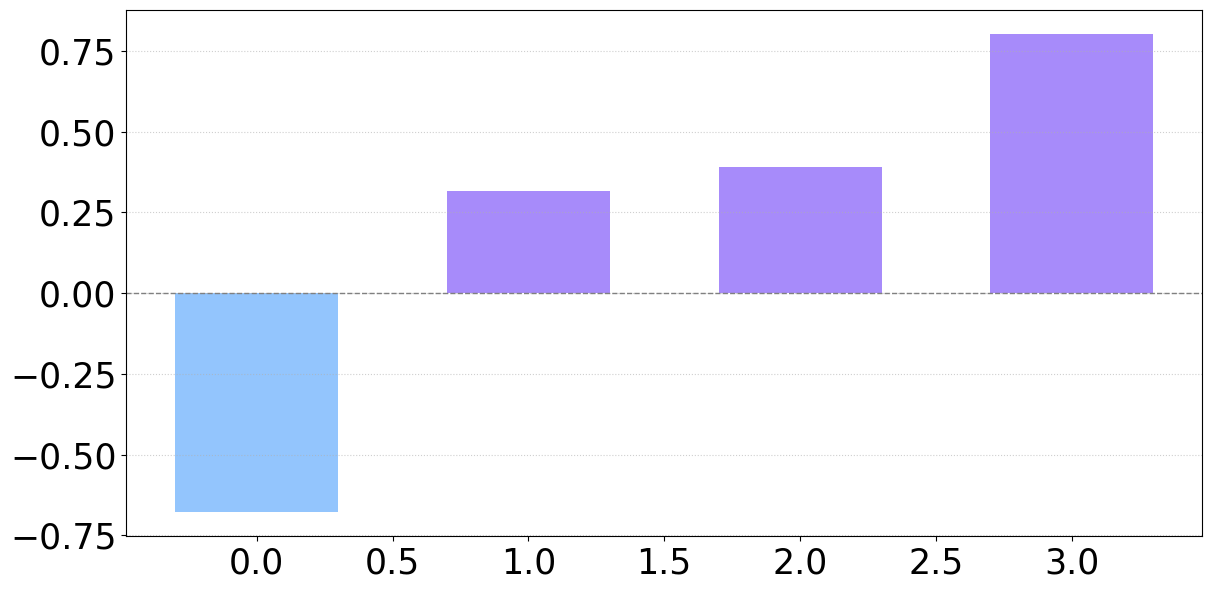

In [83]:
import statsmodels.stats.multitest as smm
summary_list_posthoc = []

for res in all_results:
    var = res['Variable']
    posthoc = res['Posthoc']
    if not posthoc:
        continue

    pvals = [ph['p_posthoc'] for ph in posthoc]
    reject, pvals_fdr, _, _ = smm.multipletests(pvals, alpha=0.05, method='fdr_bh')

    for ph, fdr_val, sig in zip(posthoc, pvals_fdr, reject):
        summary_list_posthoc.append({
            "Variable": var,
            "Global_test": res['Global_test'],
            "Global_p": res['Global_p'],
            "Condition1": ph['Cond1'],
            "Condition2": ph['Cond2'],
            "p_posthoc": ph['p_posthoc'],
            "Effect": ph['Effect'],
            "Eff_type": ph['Eff_type'],
            "p_FDR": fdr_val,
            "Significant_FDR": sig,
            "Interpretation": ph.get('Interpretation', '')
        })

summary_df_posthoc = pd.DataFrame(summary_list_posthoc)
summary_df_posthoc.to_csv("posthoc_summary_with_FDR.csv", index=False)
print("✅ Dodatni fajl sačuvan: posthoc_summary_with_FDR.csv")


# --- Filter for Ride vs Fog and significant comparisons ---
sig_df = summary_df[
    (summary_df['Significant_FDR'] == True) &
    (summary_df['Cond1'].eq('Ride')) &
    (summary_df['Cond2'].eq('Fog'))
].copy()

if not sig_df.empty:
    plt.figure(figsize=(12, 6))
    
    # Sort by effect size
    sig_df = sig_df.sort_values("Effect", ascending=True).reset_index(drop=True)
    
    # Define colors (light blue for negative, purple for positive)
    sig_df["Color"] = sig_df["Effect"].apply(lambda x: "#93c5fd" if x < 0 else "#a78bfa")
    
    # Create x positions for bars
    x_pos = np.arange(len(sig_df))
    
    # Custom x-axis labels
    custom_labels = [
        "Median Blink Duration", "Blink Rate per Minute", 
        "Number of Blinks", "SD of Blink Duration"
    ]
    if len(custom_labels) != len(sig_df):
        custom_labels = sig_df["Variable"].tolist()  # fallback
    
    # Plot bars
    plt.bar(x_pos, sig_df["Effect"], color=sig_df["Color"], width=0.6)
    
    # Aesthetics
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tick_params(axis='x', labelsize=25)  # x-axis numbers
    plt.tick_params(axis='y', labelsize=25)  # y-axis numbers
    # Larger fonts
    #plt.xticks(x_pos, custom_labels, rotation=45, ha='right', fontsize=16)
    #plt.ylabel(r"Effect Size (Cohen’s $\it{d}$ or Cliff’s $\delta$)", fontsize=16)
    #plt.title("Significant Post-hoc Effects (Ride vs Fog, FDR-corrected)", fontsize=18)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No significant Ride vs Fog effects found after FDR correction.")


In [84]:
import pandas as pd

labels = ['Baseline','Ride','Fog']
variables = ['NumBlinks','BlinkRate_perMin','MeanDur_ms','StdDur_ms','MedianDur_ms']

# create df_long from merged
long_dfs = []

for var in variables:
    # find columns corresponding to this variable
    cols_var = [c for c in merged.columns if c.startswith(f"{var}_")]
    if not cols_var:
        continue
    
    # melt wide to long
    df_var = pd.melt(
        merged,
        id_vars='Subject',
        value_vars=cols_var,
        var_name='Condition',
        value_name='Value'
    )
    
    # clean Condition names (remove variable prefix)
    for lab in labels:
        df_var['Condition'] = df_var['Condition'].str.replace(f"{var}_{lab}", lab, regex=False)
    df_var['Condition'] = df_var['Condition'].str.strip()
    
    # add Variable column
    df_var['Variable'] = var
    long_dfs.append(df_var)

# combine all variables
df_long = pd.concat(long_dfs, ignore_index=True)


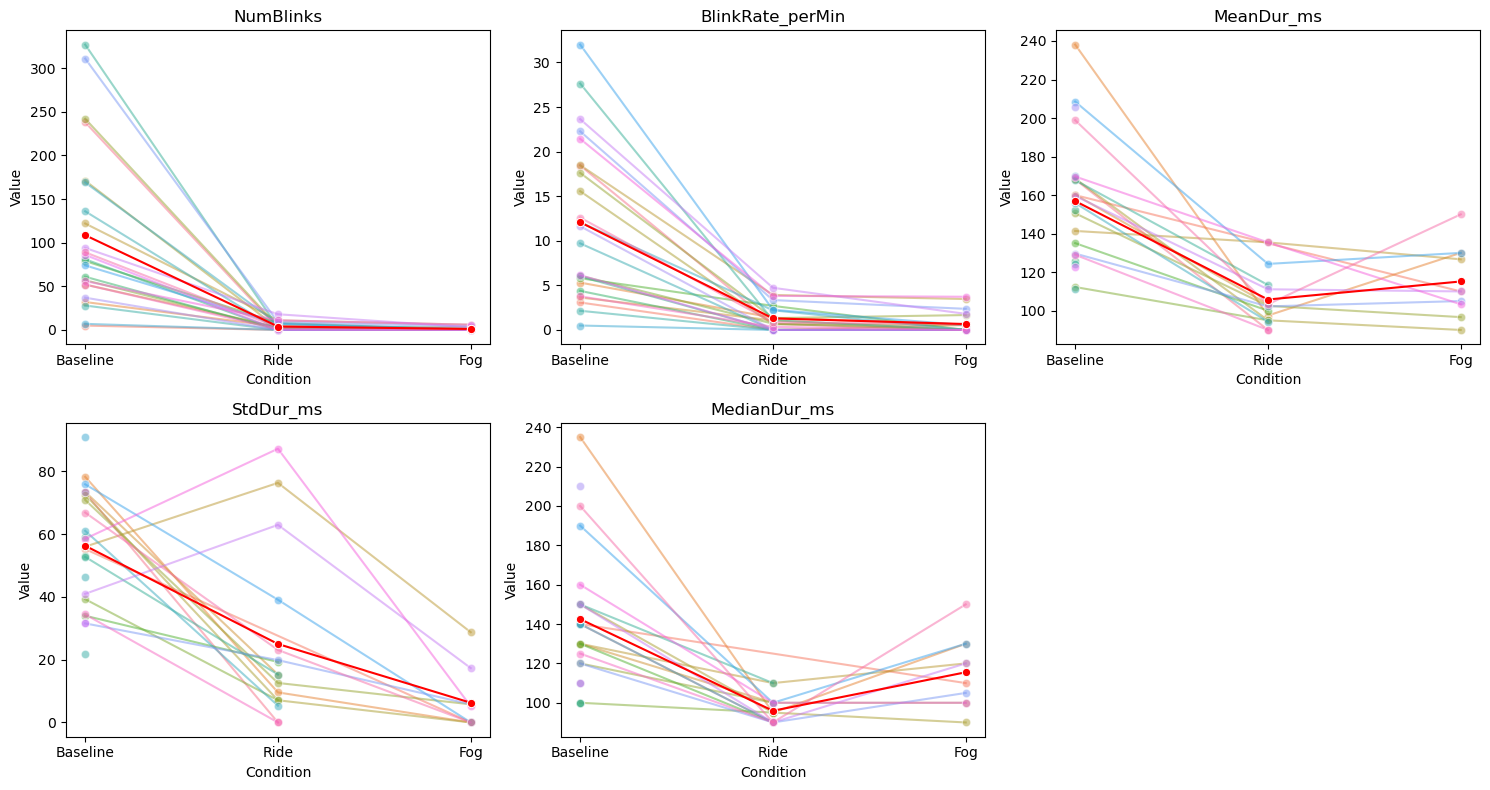

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

variables = df_long['Variable'].unique()
n_vars = len(variables)

n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Ovde ćemo staviti poslednji subplot u sredinu
    if i == n_vars-1:
        # pozicija srednjeg subplota u poslednjem redu
        center_idx = (n_rows-1)*n_cols + n_cols//2
        ax = axes[center_idx]
    else:
        ax = axes[i]

    df_var = df_long[df_long['Variable']==var]
    sns.lineplot(data=df_var, x='Condition', y='Value', hue='Subject',
                 marker='o', ax=ax, legend=False, alpha=0.5)
    df_mean = df_var.groupby('Condition')['Value'].mean().reset_index()
    sns.lineplot(data=df_mean, x='Condition', y='Value', color='red', marker='o', ax=ax)
    ax.set_title(var)

# Sakrij prazne ose ako postoje
for j in range(len(variables), len(axes)):
    if axes[j].has_data():
        continue
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [86]:
import pandas as pd

# Build df_results from all_results
summary_list = []

for res in all_results:
    var = res['Variable']
    for ph in res['Posthoc']:
        summary_list.append({
            'Variable': var,
            'Condition1': ph['Cond1'],
            'Condition2': ph['Cond2'],
            'p_posthoc': ph['p_posthoc'],
            'p_FDR': ph.get('p_FDR', np.nan),
            'Significant_FDR': ph.get('Significant_FDR', False),
            'Eff_size': ph['Effect'],
            'Eff_type': ph['Eff_type']
        })

df_results = pd.DataFrame(summary_list)


In [87]:
# # Pivot tabela sa Effect size
# pivot = df_results.pivot(index='Variable', columns=['Condition1','Condition2'], values='Eff_size')
# plt.figure(figsize=(12,6))
# sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues", center=0)
# plt.title("Effect Size (Cliff's delta) Heatmap")
# plt.show()


In [88]:
import numpy as np
import pandas as pd

# Ensure numeric data only
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])

# Common numeric columns across all three conditions
common_cols = list(set(baseline_num.columns) & set(ride_num.columns) & set(fog_num.columns))

rho_results = {}
for col in common_cols:
    try:
        data = pd.DataFrame({
            'Baseline': baseline_num[col].values,
            'Ride': ride_num[col].values,
            'Fog': fog_num[col].values
        }).dropna()
        corr_matrix = np.corrcoef(data.T)
        rho = (np.sum(corr_matrix) - np.trace(corr_matrix)) / (3 * (3 - 1))  # average off-diagonal
        rho_results[col] = rho
    except Exception as e:
        rho_results[col] = np.nan

rho_df = pd.DataFrame(list(rho_results.items()), columns=['Variable', 'Mean_within_subject_corr'])
rho_df = rho_df.sort_values('Mean_within_subject_corr', ascending=False)
# List of variables to exclude
exclude_vars = ['Time_min']

# Filter out excluded variables
rho_df_filtered = rho_df[~rho_df['Variable'].isin(exclude_vars)]

# Sort and print
rho_df_filtered = rho_df_filtered.sort_values('Mean_within_subject_corr', ascending=False)
print(rho_df_filtered)


           Variable  Mean_within_subject_corr
0  BlinkRate_perMin                  0.632798
5         NumBlinks                  0.368090
1        MeanDur_ms                  0.177475
3      MedianDur_ms                  0.091985
4         StdDur_ms                 -0.072074


In [89]:
import numpy as np
import pandas as pd
from statsmodels.stats.anova import AnovaRM
import warnings
warnings.filterwarnings("ignore")

# ---- 1. Calculate rho for each variable (filtered) ----
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])

common_cols = list(set(baseline_num.columns) & set(ride_num.columns) & set(fog_num.columns))

rho_results = {}
delta_dict = {}

for col in common_cols:
    # Create data matrix for correlation
    data = pd.DataFrame({
        'Baseline': baseline_num[col].values,
        'Ride': ride_num[col].values,
        'Fog': fog_num[col].values
    }).dropna()
    
    # Compute mean within-subject correlation
    corr_matrix = np.corrcoef(data.T)
    rho = (np.sum(corr_matrix) - np.trace(corr_matrix)) / (3 * (3 - 1))
    rho_results[col] = rho
    
    # Compute delta from means
    means = data.mean().values
    centered_means = means - np.mean(means)
    sd_within = data.std(axis=0, ddof=1).mean()  # average SD across conditions
    delta = (np.max(centered_means) - np.min(centered_means)) / 2 / sd_within
    delta_dict[col] = delta

# Filter variables if needed (example: exclude Time_min and StdDur_ms)
exclude_vars = ['Time_min', 'StdDur_ms']
rho_results = {k: v for k, v in rho_results.items() if k not in exclude_vars}
delta_dict = {k: v for k, v in delta_dict.items() if k not in exclude_vars}

# ---- 2. Power simulation function ----
def rm_anova_pval(long_df):
    a = AnovaRM(long_df, 'score', 'subject', within=['condition']).fit()
    return a.anova_table['Pr > F'][0]

def simulate_rm_power(n_subj=24, k=3, rho=0.5, delta=0.8, alpha=0.05, n_sim=500, seed=123):
    rng = np.random.default_rng(seed)
    cov = np.full((k, k), rho)
    np.fill_diagonal(cov, 1.0)
    means = np.linspace(-delta, delta, k)
    reject = 0
    for _ in range(n_sim):
        data = rng.multivariate_normal(mean=means, cov=cov, size=n_subj)
        df = pd.DataFrame(data, columns=[f'Cond{j+1}' for j in range(k)])
        df['subject'] = np.arange(n_subj)
        long_df = df.melt(id_vars='subject', var_name='condition', value_name='score')
        pval = rm_anova_pval(long_df)
        if pval < alpha:
            reject += 1
    return reject / n_sim

# ---- 3. Run power simulations for each variable ----
power_results = {}
for var in rho_results.keys():
    rho = rho_results[var]
    delta = delta_dict[var]
    power = simulate_rm_power(n_subj=24, k=3, rho=rho, delta=delta, alpha=0.05, n_sim=500)
    power_results[var] = power

# ---- 4. Collect results ----
power_df = pd.DataFrame({
    'Variable': list(power_results.keys()),
    'Delta': [delta_dict[v] for v in power_results.keys()],
    'Rho': [rho_results[v] for v in power_results.keys()],
    'EstimatedPower': [power_results[v] for v in power_results.keys()]
}).sort_values('EstimatedPower', ascending=False)

print(power_df)


           Variable     Delta       Rho  EstimatedPower
0  BlinkRate_perMin  1.499415  0.632798             1.0
1        MeanDur_ms  1.324100  0.177475             1.0
2      MedianDur_ms  1.500292  0.091985             1.0
3         NumBlinks  1.661180  0.368090             1.0


In [90]:
import numpy as np
import pandas as pd
from statsmodels.stats.anova import AnovaRM
import warnings
warnings.filterwarnings("ignore")

# ---- 1. Calculate rho and standardized delta for each variable ----
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])

common_cols = list(set(baseline_num.columns) & set(ride_num.columns) & set(fog_num.columns))

rho_dict = {}
delta_dict = {}

for col in common_cols:
    # Filter data and remove NaNs
    data = pd.DataFrame({
        'Baseline': baseline_num[col],
        'Ride': ride_num[col],
        'Fog': fog_num[col]
    }).dropna()

    # Mean within-subject correlation
    corr_matrix = np.corrcoef(data.T)
    rho = (np.sum(corr_matrix) - np.trace(corr_matrix)) / (3 * (3 - 1))
    rho_dict[col] = rho

    # Standardized delta (effect size in SD units)
    means = data.mean().values
    centered_means = means - np.mean(means)
    sd_within = data.std(axis=0, ddof=1).mean()  # average SD across conditions
    delta = (np.max(centered_means) - np.min(centered_means)) / 2 / sd_within
    delta_dict[col] = delta

# Optional: exclude variables
exclude_vars = ['Time_min', 'StdDur_ms']
rho_dict = {k: v for k, v in rho_dict.items() if k not in exclude_vars}
delta_dict = {k: v for k, v in delta_dict.items() if k not in exclude_vars}

# ---- 2. Power simulation functions ----
def rm_anova_pval(long_df):
    a = AnovaRM(long_df, 'score', 'subject', within=['condition']).fit()
    return a.anova_table['Pr > F'][0]

def simulate_rm_power(n_subj=24, k=3, rho=0.5, delta=0.8, alpha=0.05, n_sim=500, seed=123):
    rng = np.random.default_rng(seed)
    cov = np.full((k, k), rho)
    np.fill_diagonal(cov, 1.0)
    means = np.linspace(-delta, delta, k)
    reject = 0
    for _ in range(n_sim):
        data = rng.multivariate_normal(mean=means, cov=cov, size=n_subj)
        df = pd.DataFrame(data, columns=[f'Cond{j+1}' for j in range(k)])
        df['subject'] = np.arange(n_subj)
        long_df = df.melt(id_vars='subject', var_name='condition', value_name='score')
        pval = rm_anova_pval(long_df)
        if pval < alpha:
            reject += 1
    return reject / n_sim

# ---- 3a. Conservative overall power (smallest delta) ----
min_delta_var = min(delta_dict, key=delta_dict.get)
conservative_power = simulate_rm_power(
    n_subj=24, k=3, rho=rho_dict[min_delta_var], delta=delta_dict[min_delta_var], alpha=0.05, n_sim=500
)
print(f"Conservative overall power (smallest delta variable '{min_delta_var}'): {conservative_power:.3f}")

# ---- 3b. Average overall power ----
avg_delta = np.mean(list(delta_dict.values()))
avg_rho = np.mean(list(rho_dict.values()))

average_power = simulate_rm_power(
    n_subj=24, k=3, rho=avg_rho, delta=avg_delta, alpha=0.05, n_sim=500
)
print(avg_delta)
print(avg_rho)
print(f"Average overall power (mean delta & mean rho): {average_power:.3f}")


Conservative overall power (smallest delta variable 'MeanDur_ms'): 1.000
1.4962465767851367
0.3175868489539081
Average overall power (mean delta & mean rho): 1.000
